In [1]:
using Pkg
using Metal

cd(@__DIR__)
Pkg.activate("../")
ParamFile = "../config/testparam.csv"  # maybe GeoPoints and planet1D should be fusioned

# batchGPU should be at this level (I have not made it as a module yet, since the choice of Metal/CUDA should be done in a manual way)
include("../src/batchFiles/batchGPU.jl")


include("../src/commonBatchs.jl")
#include("../src/flexOPT.jl")
include("../src/planet1D.jl")
include("../src/GeoPoints.jl")

  Activating 

devs = Metal.devices() = Metal.MTL.MTLDeviceInstance[Metal.MTL.MTLDeviceInstance (object of type AGXG13XDevice)]

project at `~/Documents/Github/flexOPT`



→ Using Metal backend (1 device(s))
Selected backend type: MetalBackend


Main.GeoPoints

In [2]:
using .commonBatchs, UnPack, Symbolics

In [130]:
include("../src/compactSymbolicFunctions/compactFunctionsArray.jl")
include("../src/compactSymbolicFunctions/BsplineHelpers.jl")
include("../src/CompactSymbolicFunctions/TaylorExpansionHelpers.jl")

plotTaylorExpansions (generic function with 1 method)

# input parameters

for B-spline

In [ ]:
orderBspline1D = 2
YorderBspline1D = 3
#the coordinate in Δy is (as usual) with the offset 1
μᶜs = [1,1.5,2.5,3] # ∈ R for variable, the nodes for interpolated Taylor expansions
μs = [1,1.5,2.5,3] # ∈ R for field, the nodes for interpolated Taylor expansions
nodesFromOne = [1,2,3] # ∈ Z like [1,2,3], an array of integers collect(1:1:N) (nothing else!!)
ν = [2] # this should be one point (for the moment)

1-element Vector{Int64}:
 2

for Taylor expansion

In [17]:
lᶜ_nᶜ_max = 4 # variable
l_n_max = 4 # field


4

for ill-posed inversion of Taylor expansion coefficients

In [7]:
Δ = 1.0 # Float64


1.0

In [ ]:

paramsforWYYKKIntegral = (orderBspline1D=orderBspline1D, YorderBspline1D=YorderBspline1D, μᶜs=μᶜs, μs=μs, nodesFromOne=nodesFromOne, ν=ν, Δ=Δ, l_n_max=l_n_max, lᶜ_nᶜ_max=lᶜ_nᶜ_max)

# starting 'WYYKKIntegral1D(paramsforWYYKKIntegral)'

In [ ]:
# Δ should be strictly Float64

    # orders: -1 -> indicator function, 0 -> box car, >=1 -> B-spline

    # this computes the analytical value of the 1D integral between B-spline fns and weighted Taylor kernels
    # \int dx Bspline Y_μᶜ Y_μ  K_{lᶜ-nᶜ}(y-y_μᶜ) K_{l-n}(y-y_μ)

    # unlike the previous integralBsplineTaylorKernels1D, it computes for a specific ν
    # Cˡη;μ are computed for a specific geometry, so even though the boundary condition reduces
    # the number of available points, each Taylor expansion for K_{l-n}(y-y_μ) should be Ok

    @unpack orderBspline1D, YorderBspline1D, μᶜs, μs, nodesFromOne, ν, Δ, l_n_max, lᶜ_nᶜ_max = paramsforWYYKKIntegral


# preparation of B-splines (all these things should be inside the package)

In [18]:


allNodes = unique(sort(vcat(
    Float64.(nodesFromOne),
    Float64.(ν),
    Float64.(μs),
    Float64.(μᶜs),
)))

to_indices(xs, master) = searchsortedfirst.(Ref(master), Float64.(xs))

idx_nodesFromOne = to_indices(nodesFromOne, allNodes)
idx_ν            = to_indices(ν, allNodes)
idx_μs           = to_indices(μs, allNodes)
idx_μᶜs          = to_indices(μᶜs, allNodes)



4-element Vector{Int64}:
 1
 2
 4
 5

In [47]:
# for B-spline

paramsBSν  = (maximumOrder=orderBspline1D, allNodes = allNodes, idx_nodesNum = idx_nodesFromOne, idx_refPoints = idx_nodesFromOne, idx_selectedPoints = idx_ν)
paramsBSμᶜ = (maximumOrder=YorderBspline1D, allNodes = allNodes, idx_nodesNum = idx_nodesFromOne, idx_refPoints = idx_μs, idx_selectedPoints = idx_μᶜs)
paramsBSμ  = (maximumOrder=YorderBspline1D, allNodes = allNodes, idx_nodesNum = idx_nodesFromOne, idx_refPoints = idx_μs, idx_selectedPoints = idx_μs)
# idx_nodesNum : an ordinary consecutive integer increment from 1 (the numerical nodes with Δy)
# idx_refPoints_original : supporting nodes to construct the Bspline family
# idx_selectedPoints  : the node addresses that user needs to take, should be a subset of idx_refPoints_original


# for Taylor Expansions

paramsTEμᶜ = (maxL_MINUS_N=lᶜ_nᶜ_max, allNodes = allNodes, idx_nodesNum = idx_nodesFromOne, idx_selectedPoints = idx_μᶜs)
paramsTEμ  = (maxL_MINUS_N=l_n_max, allNodes = allNodes, idx_nodesNum = idx_nodesFromOne, idx_selectedPoints = idx_μs)




(maxL_MINUS_N = 4, allNodes = [1.0, 1.5, 2.0, 2.5, 3.0], idx_nodesNum = [1, 3, 5], idx_selectedPoints = [1, 2, 4, 5])

# computing $Y_\mu$, $Y_{\mu^\prime}$, $W_\nu$

In [20]:
Wν = constructBsplineFamily(paramsBSν);
Yμᶜ = constructBsplineFamily(paramsBSμᶜ);
Yμ = constructBsplineFamily(paramsBSμ);

In [23]:
Wν.b

CompactSymbolicFunctions{2, Array{Num, 4}}(5, 1, (3, 3), Num[x, Δx], Num[1.0, 1.5, 2.0, 2.5, 3.0], Num[0; 0; … ; 1; 0;;; 0; 0; … ; 0; 0;;; 0; 0; … ; 0; 0;;;; (x - Δx) / Δx; (x - Δx) / Δx; … ; (-x + 3.0Δx) / Δx; 0;;; 1 / Δx; 1 / Δx; … ; -1.0 / Δx; 0;;; 0; 0; … ; 0; 0;;;; (x^2 - 2x*Δx + Δx^2) / (2.0(Δx^2)); (x^2 - 2x*Δx + Δx^2) / (2.0(Δx^2)); … ; (-(x^2) + 6.0x*Δx - 8.0(Δx^2)) / (2.0(Δx^2)) + (-(x^2) + 4.0x*Δx - 3.0(Δx^2)) / (2.0(Δx^2)); 0;;; (2x - 2Δx) / (2.0(Δx^2)); (2x - 2Δx) / (2.0(Δx^2)); … ; (-8.0x + 20.0Δx) / (4.0(Δx^2)); 0;;; 2 / (2.0(Δx^2)); 2 / (2.0(Δx^2)); … ; -8.0 / (4.0(Δx^2)); 0])

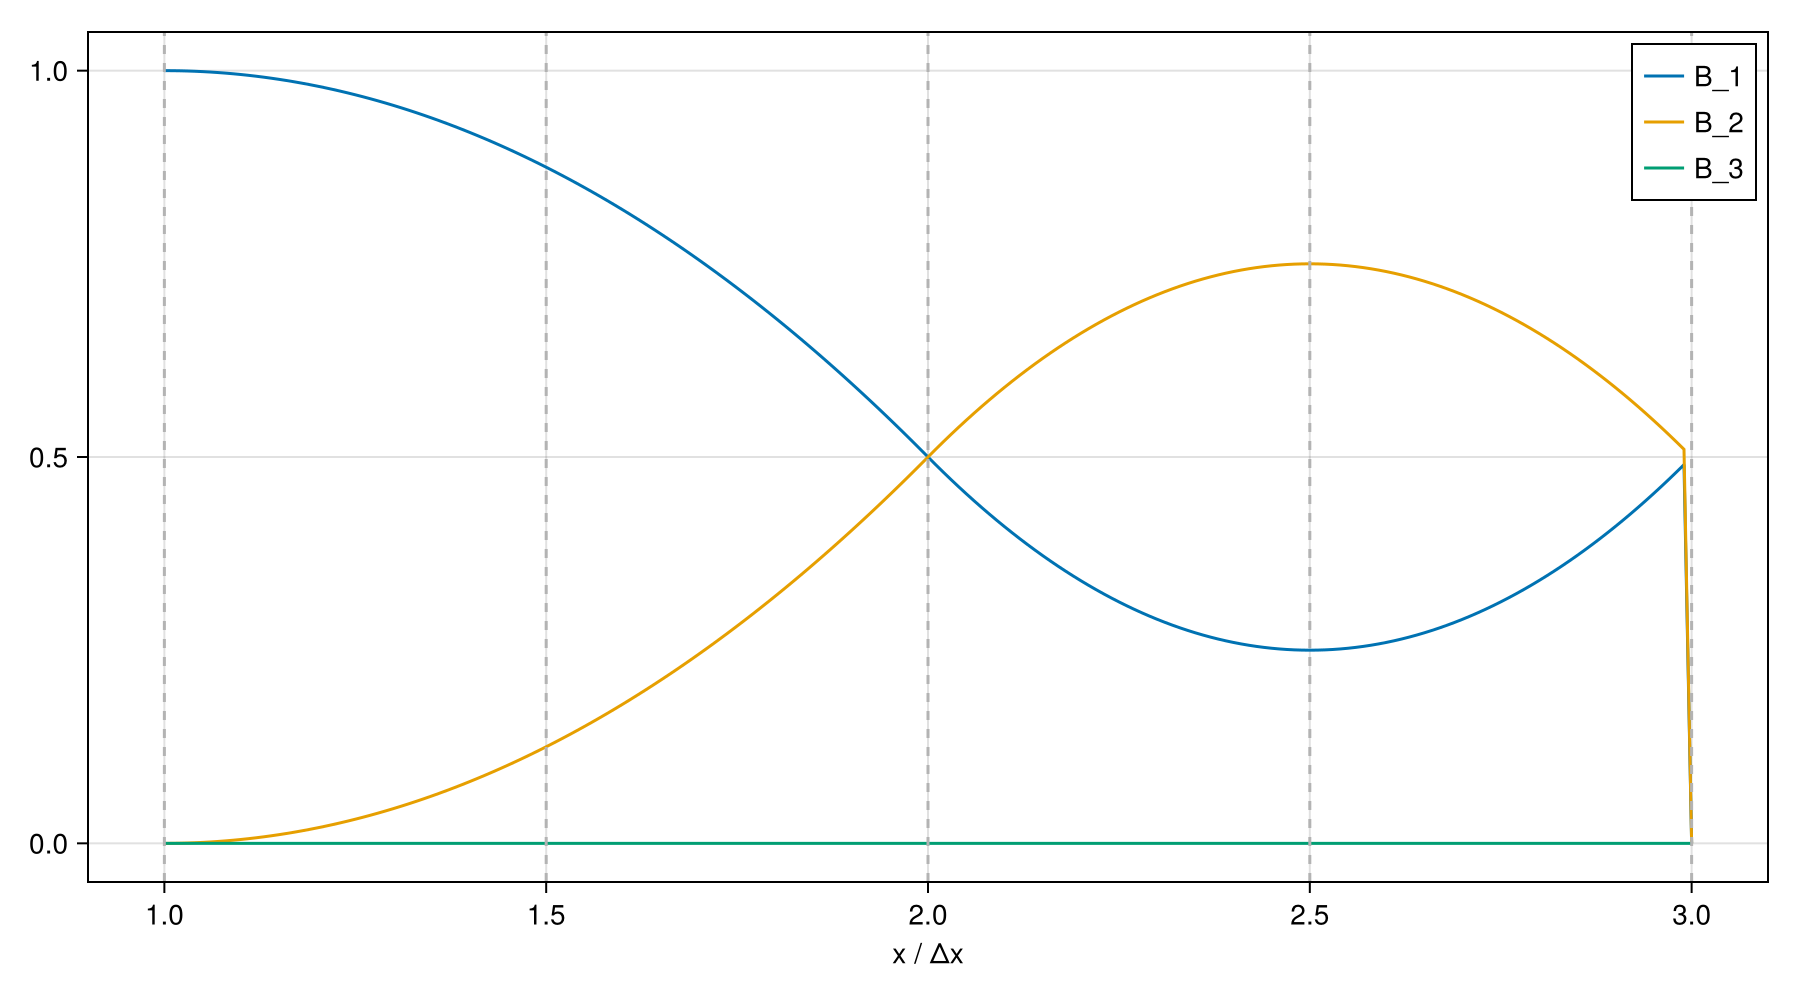

CairoMakie.Screen{IMAGE}


In [41]:

fig=plotBSpline(Wν.b_support; derivOrder=0,order=2, N=50)
display(fig)

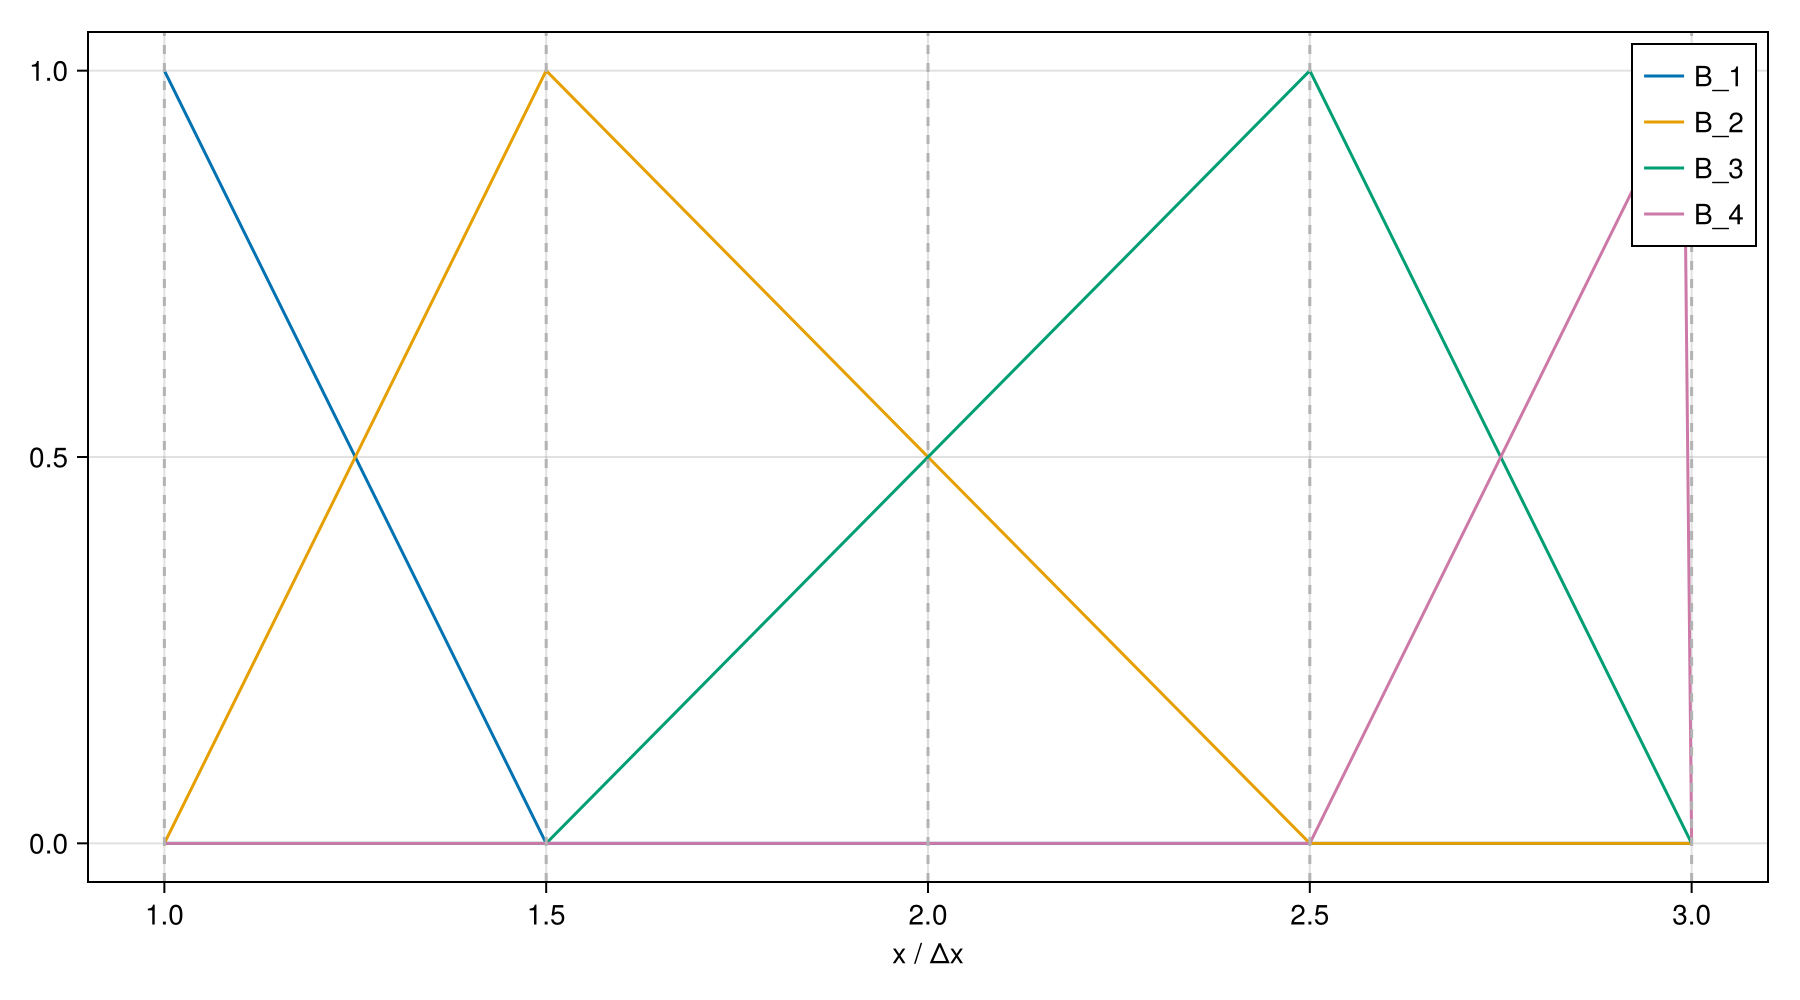

In [44]:
plotBSpline(Yμ.b; derivOrder=0, order=1, N=50)

# computing $K_\mu$, $K_{\mu^\prime}$

In [95]:
Kμᶜ=constructTaylorExpansions(paramsTEμᶜ) 
Kμ=constructTaylorExpansions(paramsTEμ) 

(k = CompactSymbolicFunctions{1, Array{Num, 3}}(5, 4, (5,), Num[x, Δx], Num[1.0, 1.5, 2.0, 2.5, 3.0], Num[1.0 1.0 1.0 1.0; 1.0 1.0 1.0 1.0; … ; 1.0 1.0 1.0 1.0; 1.0 1.0 1.0 1.0;;; x - Δx x - 1.5Δx x - 2.5Δx x - 3.0Δx; x - Δx x - 1.5Δx x - 2.5Δx x - 3.0Δx; … ; x - Δx x - 1.5Δx x - 2.5Δx x - 3.0Δx; x - Δx x - 1.5Δx x - 2.5Δx x - 3.0Δx;;; 0.5((x - Δx)^2) 0.5((x - 1.5Δx)^2) 0.5((x - 2.5Δx)^2) 0.5((x - 3.0Δx)^2); 0.5((x - Δx)^2) 0.5((x - 1.5Δx)^2) 0.5((x - 2.5Δx)^2) 0.5((x - 3.0Δx)^2); … ; 0.5((x - Δx)^2) 0.5((x - 1.5Δx)^2) 0.5((x - 2.5Δx)^2) 0.5((x - 3.0Δx)^2); 0.5((x - Δx)^2) 0.5((x - 1.5Δx)^2) 0.5((x - 2.5Δx)^2) 0.5((x - 3.0Δx)^2);;; 0.1666666666666666666666666666666666666666666666666666666666666666666666666666674((x - Δx)^3) 0.1666666666666666666666666666666666666666666666666666666666666666666666666666674((x - 1.5Δx)^3) 0.1666666666666666666666666666666666666666666666666666666666666666666666666666674((x - 2.5Δx)^3) 0.1666666666666666666666666666666666666666666666666666666666666666666666

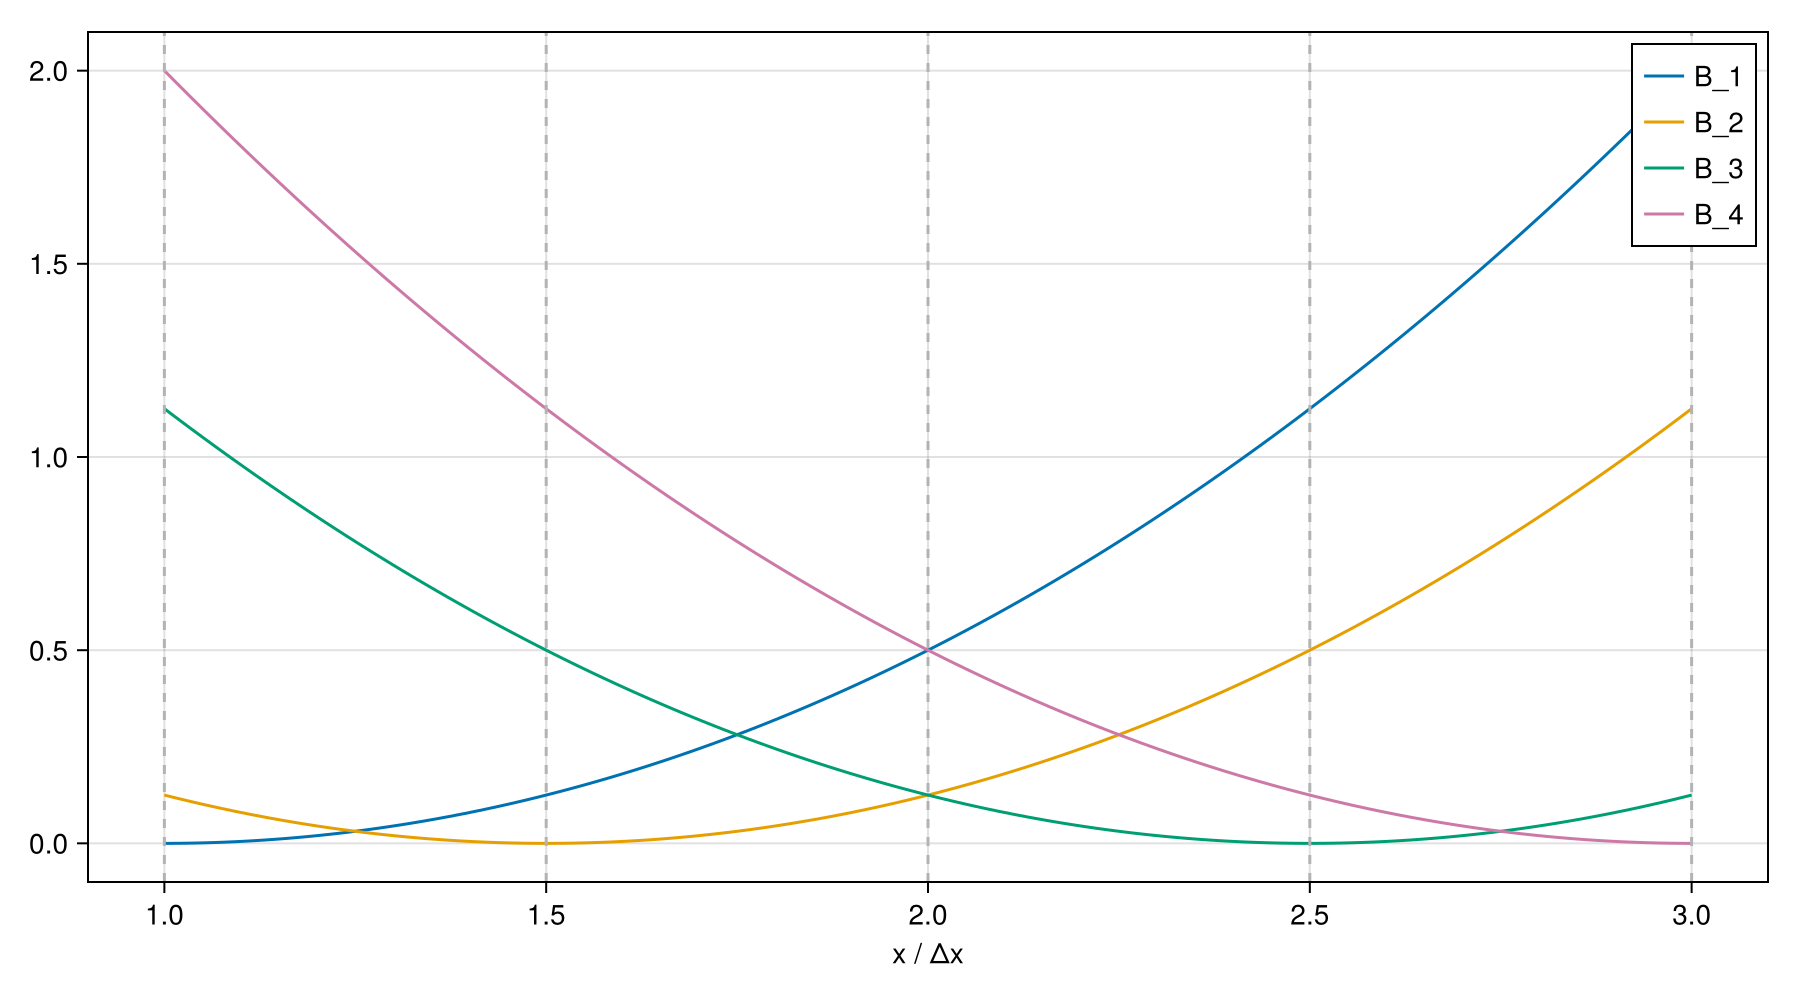

In [96]:
plotTaylorExpansions(Kμᶜ.k; l_n=2, N=50)

# constructing WYYKK functions

In [139]:
WYYKK=CompactSymbolicFunctions(Yμ.b.nodes,1;auxDims=(l_n_max+1, lᶜ_nᶜ_max+1, length(μs),length(μᶜs),),variables=Yμ.b.variables)
YorderSlot = YorderBspline1D + 1 
orderSlot = orderBspline1D + 1
derivSlot = 1 # no derivatives
for iμᶜ ∈ eachindex(μᶜs), iμ ∈ eachindex(μs), lᶜ_nᶜ ∈ 0:lᶜ_nᶜ_max, l_n ∈ 0:l_n_max
    l_n_slot=l_n+1
    lᶜ_nᶜ_slot = lᶜ_nᶜ+1
    WYYKK.data[:,1,l_n_slot, lᶜ_nᶜ_slot, iμ, iμᶜ] = Wν.b.data[:,1,derivSlot,orderSlot].*Yμᶜ.b.data[:,iμᶜ,derivSlot,YorderSlot].*Yμ.b.data[:,iμ,derivSlot,YorderSlot].*Kμᶜ.k.data[:,iμᶜ,lᶜ_nᶜ_slot].*Kμ.k.data[:,iμ,l_n_slot]
end

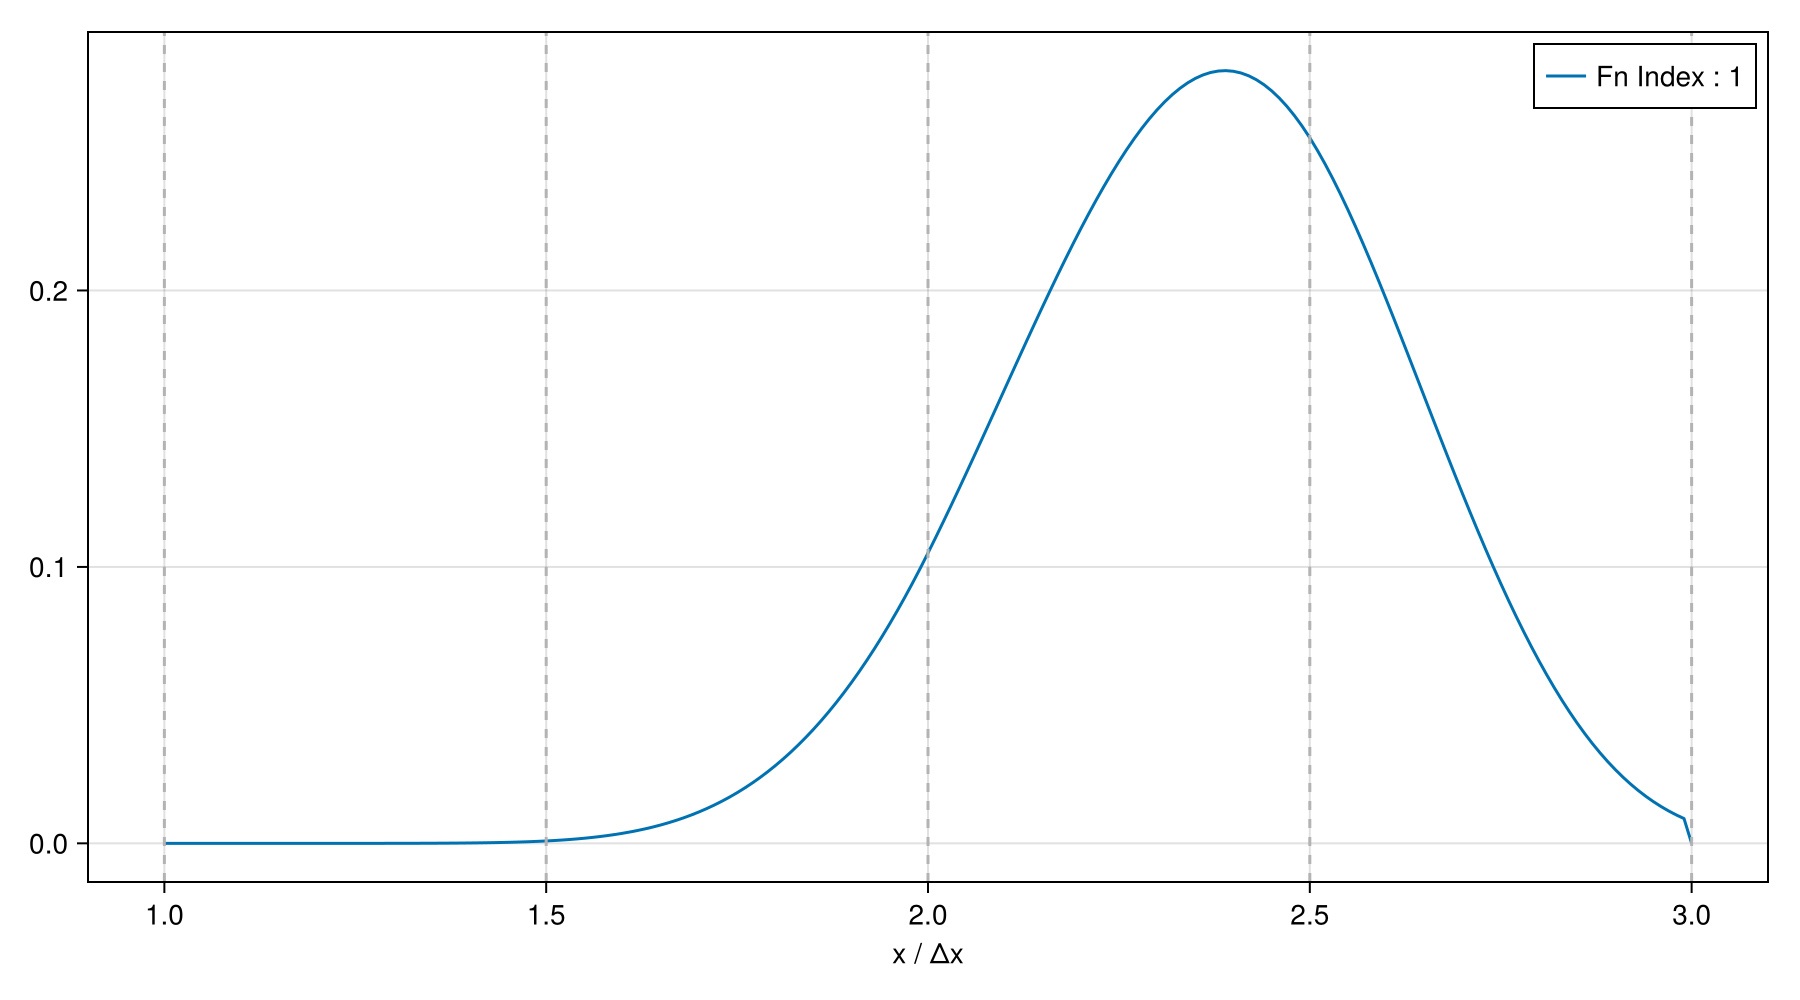

In [157]:
plotCompactSymbolicFunctions(WYYKK,(1,1,3,3,);N=50)

In [153]:
WYYKK.nodes

5-element Vector{Num}:
 1.0
 1.5
 2.0
 2.5
 3.0

In [155]:
WYYKK.data[:,1,1,1,4,4]

5-element Vector{Num}:
                                                                                                                                                                                                                0.0
                                                                                                                                                                                                                0.0
                                                                                                                                                                                                                0.0
 (((-1.0546875(x^3) + 8.54296875(x^2)*Δx - 22.306640625x*(Δx^2) + 19.0634765625(Δx^3))^2)*((-(x^2) + 6.0x*Δx - 8.0(Δx^2)) / (2.0(Δx^2)) + (-(x^2) + 4.0x*Δx - 3.0(Δx^2)) / (2.0(Δx^2)))) / (0.40045166015625(Δx^6))
                                                                                                                                 

# making analytic integrals

In [150]:
WYYKK_integral=lazyProduceOrLoad("WYYKK_integral_tmp",integrate,WYYKK,x)


Computing WYYKK_integral_tmp


CompactSymbolicFunctions{4, Array{Num, 6}}(5, 1, (5, 5, 4, 4), Num[x, Δx], Num[1.0, 1.5, 2.0, 2.5, 3.0], Num[(0.026125568351839247(x^9) - 0.28803439107902773(x^8)*Δx + 1.360731566485296(x^7)*(Δx^2) - 3.5818154210371613(x^6)*(Δx^3) + 5.718717096023325(x^5)*(Δx^4) - 5.6491479731984215(x^4)*(Δx^5) + 3.377105264520281(x^3)*(Δx^6) - 1.1472880056908008(x^2)*(Δx^7) + 0.20118320478938212x*(Δx^8)) / (0.16929368291991834(Δx^8)); (1.7395736349518342e36(x^7) - 2.0295025741104732e37(x^6)*Δx + 1.0025742716105738e38(x^5)*(Δx^2) - 2.7093859364374818e38(x^4)*(Δx^3) + 4.309592341052087e38(x^3)*(Δx^4) - 4.019260722811283e38(x^2)*(Δx^5) + 2.030348200183019e38x*(Δx^6)) / (2.4354030889325675e37(Δx^6)); … ; 0.0; 0.0;;; (0.023513011516655326(x^10) - 0.2821561381998639(x^9)*Δx + 1.4786745117536617(x^8)*(Δx^2) - 4.430859070231434(x^7)*(Δx^3) + 8.347413001056598(x^6)*(Δx^4) - 10.238035474582063(x^5)*(Δx^5) + 8.18197692158863(x^4)*(Δx^6) - 4.141963934980814(x^3)*(Δx^7) + 1.2478796080854917(x^2)*(Δx^8) - 0.2011832

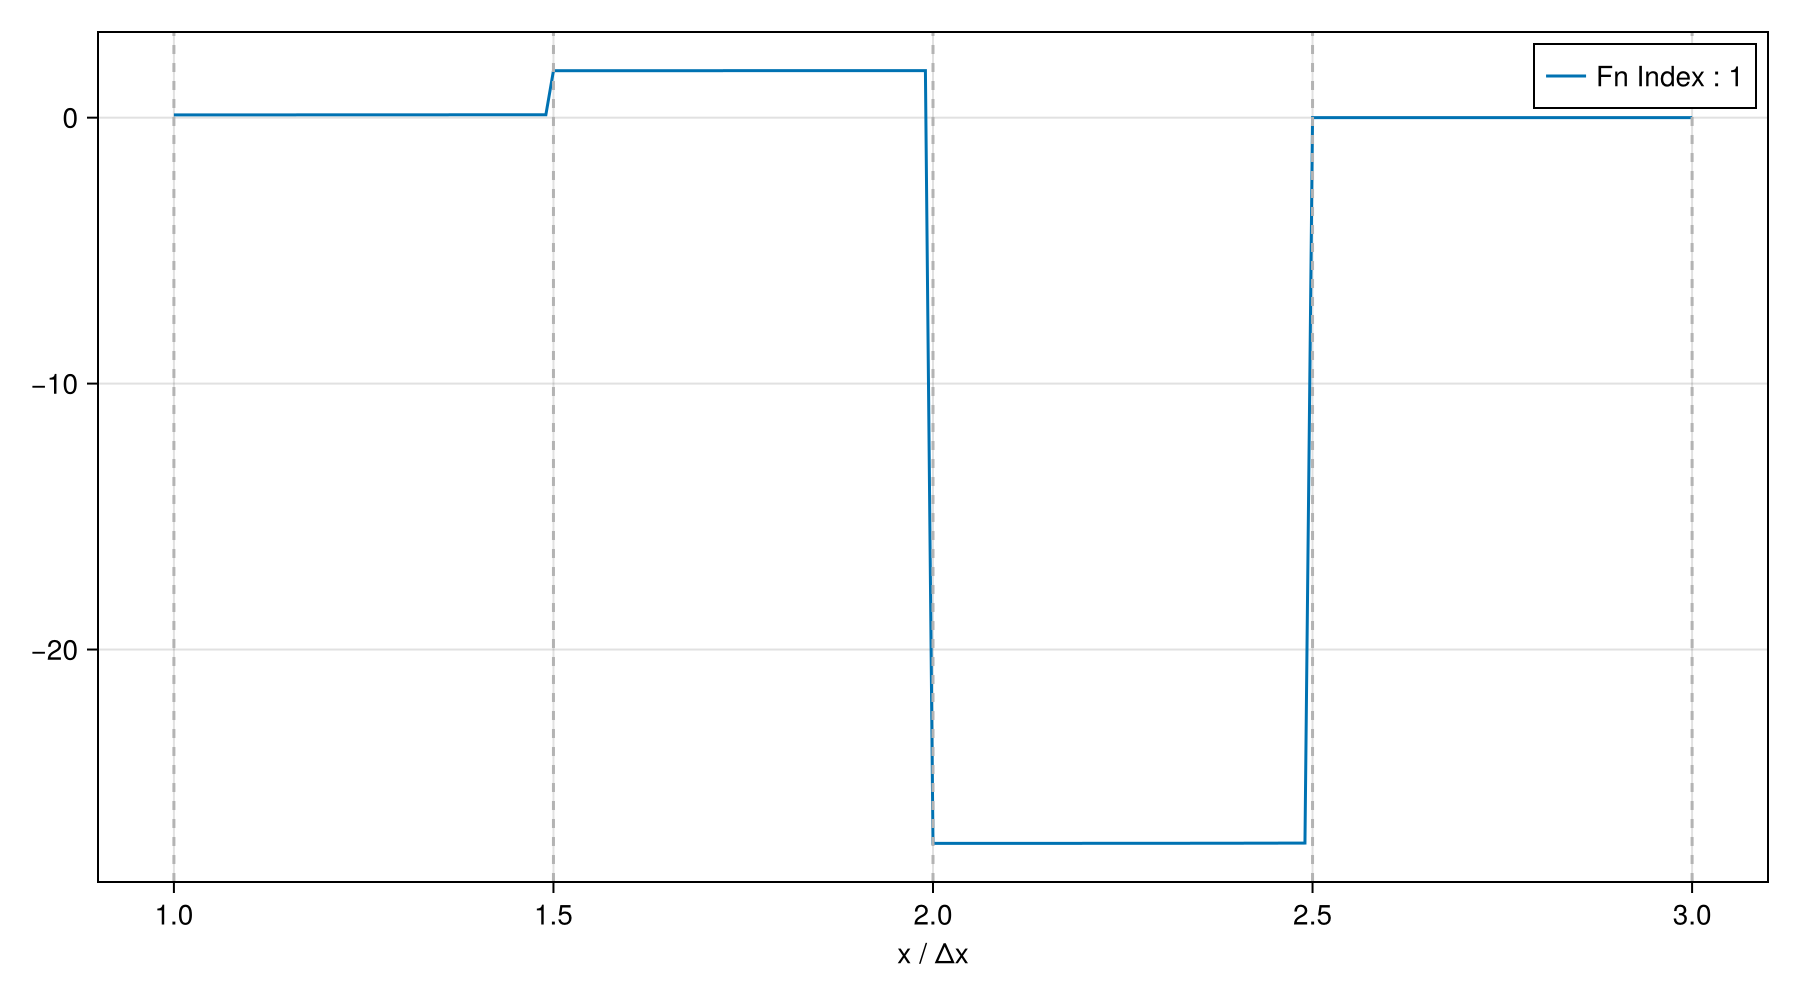

In [151]:
plotCompactSymbolicFunctions(WYYKK_integral,(1,1,1,1,);N=50)

In [152]:
WYYKK_recovered=differentiate(WYYKK_integral,x)

CompactSymbolicFunctions{4, Array{Num, 6}}(5, 1, (5, 5, 4, 4), Num[x, Δx], Num[1.0, 1.5, 2.0, 2.5, 3.0], Num[(0.23513011516655322(x^8) - 2.304275128632222(x^7)*Δx + 9.525120965397072(x^6)*(Δx^2) - 21.490892526222968(x^5)*(Δx^3) + 28.593585480116626(x^4)*(Δx^4) - 22.596591892793686(x^3)*(Δx^5) + 10.131315793560843(x^2)*(Δx^6) - 2.2945760113816016x*(Δx^7) + 0.20118320478938212(Δx^8)) / (0.16929368291991834(Δx^8)); (1.217701544466284e37(x^6) - 1.217701544466284e38(x^5)*Δx + 5.012871358052869e38(x^4)*(Δx^2) - 1.0837543745749927e39(x^3)*(Δx^3) + 1.292877702315626e39(x^2)*(Δx^4) - 8.038521445622566e38x*(Δx^5) + 2.030348200183019e38(Δx^6)) / (2.4354030889325675e37(Δx^6)); … ; 0; 0;;; (0.23513011516655327(x^9) - 2.5394052437987753(x^8)*Δx + 11.829396094029294(x^7)*(Δx^2) - 31.016013491620036(x^6)*(Δx^3) + 50.08447800633959(x^5)*(Δx^4) - 51.19017737291031(x^4)*(Δx^5) + 32.72790768635452(x^3)*(Δx^6) - 12.425891804942442(x^2)*(Δx^7) + 2.4957592161709834x*(Δx^8) - 0.20118320478938212(Δx^9)) / (0.1

# don't be shocked since the costant is set to be 0 everywhere (if you want, you can correct but I don't need it)

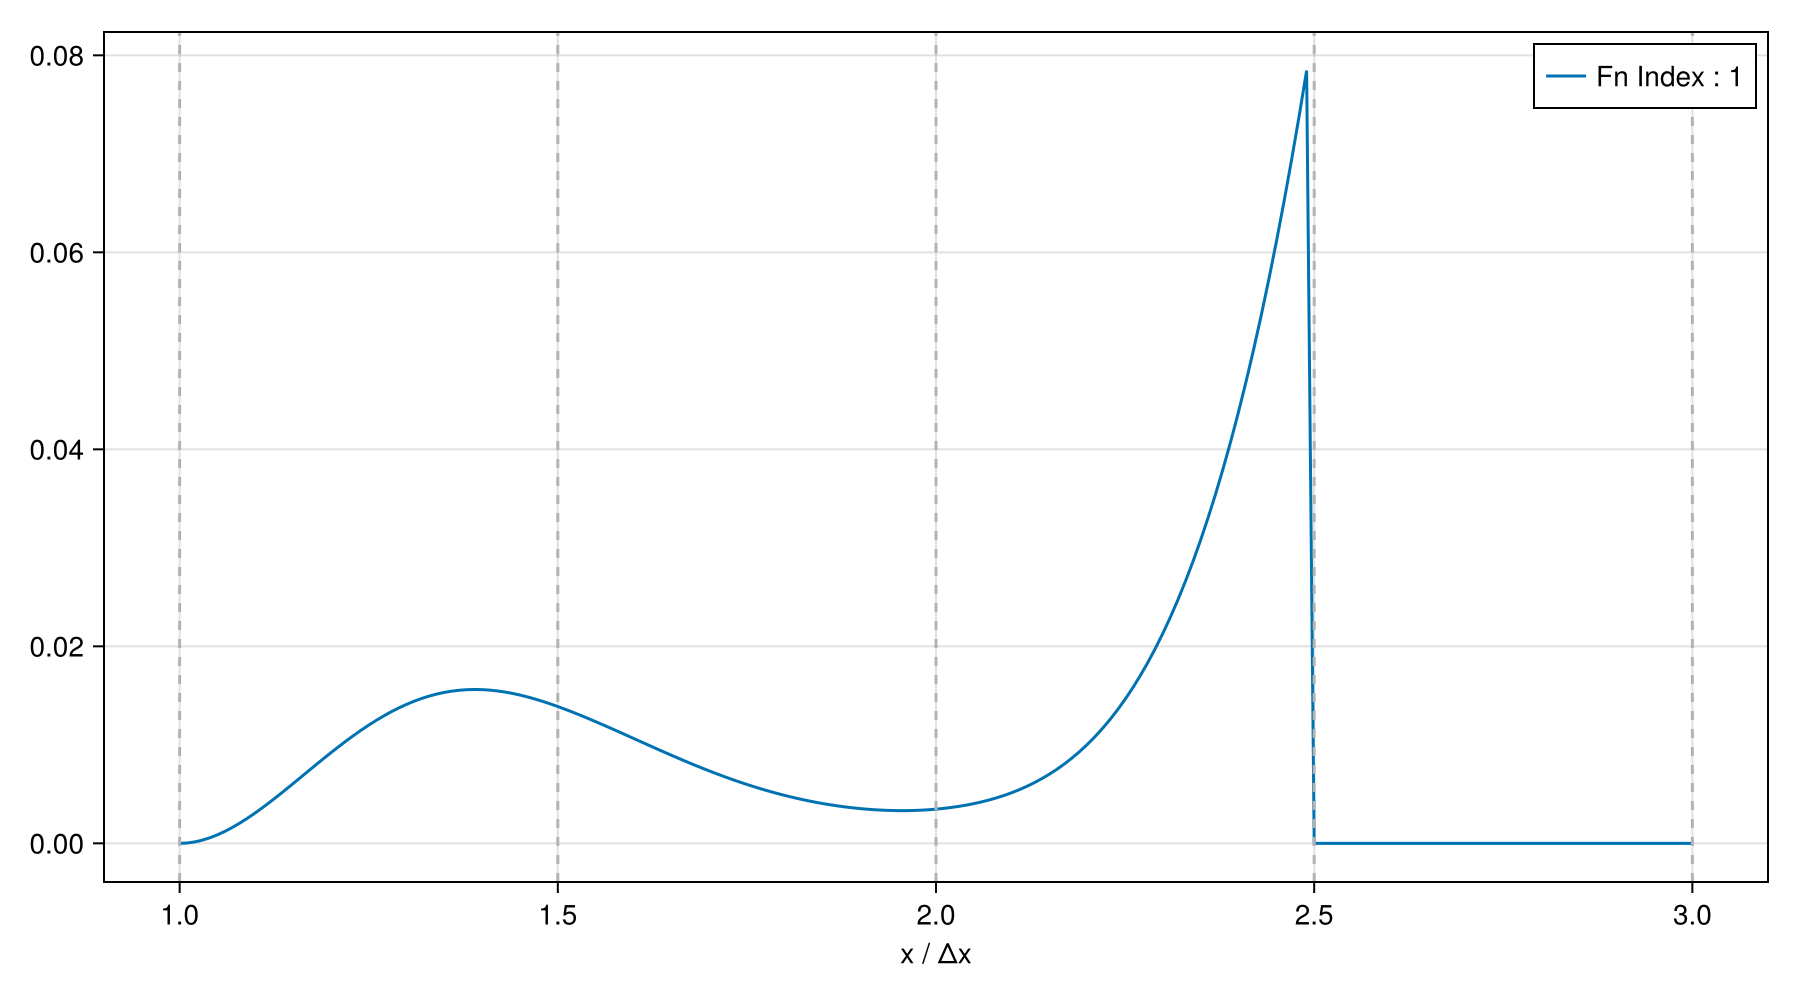

In [146]:
plotCompactSymbolicFunctions(WYYKK_recovered,(1,1,1,1,);N=50)

# now putting numerical Δx to have the WYYKK values 

In [163]:
coefWYYKK = Array{Float64, 4}(undef,l_n_max+1,lᶜ_nᶜ_max+1,length(μs),length(μᶜs))

nodes = WYYKK_integral.nodes
numericalNodes = Δ .* nodes
numNodes = WYYKK_integral.numberNodes
x = WYYKK_integral.variables[1]
Δx = WYYKK_integral.variables[2]
for iμᶜ ∈ eachindex(μᶜs), iμ ∈ eachindex(μs), lᶜ_nᶜ ∈ 0:lᶜ_nᶜ_max, l_n ∈ 0:l_n_max
    l_n_slot=l_n+1
    lᶜ_nᶜ_slot = lᶜ_nᶜ+1
    tmpAntiDerivative=WYYKK_integral.data[:,1,l_n_slot, lᶜ_nᶜ_slot, iμ, iμᶜ]
    tmpCoef = 0.0
    for ι in 1:numNodes-1
        xLeft = numericalNodes[ι]
        xRight = numericalNodes[ι+1]
        expr = tmpAntiDerivative[ι]
        rightValue = Symbolics.value(Symbolics.substitute(expr, Dict(x => xRight, Δx => Δ)))
        leftValue = Symbolics.value(Symbolics.substitute(expr, Dict(x => xLeft, Δx => Δ)))
        tmpCoef += rightValue-leftValue
    end
    coefWYYKK[l_n_slot,lᶜ_nᶜ_slot,iμ,iμᶜ] = tmpCoef
end

In [164]:
coefWYYKK

5×5×4×4 Array{Float64, 4}:
[:, :, 1, 1] =
 0.0203631   0.0204007   0.0124737   0.00549707   0.00187755
 0.0204007   0.0249473   0.0164912   0.00751018   0.00260666
 0.0124737   0.0164912   0.0112653   0.00521332   0.00182629
 0.00549707  0.00751018  0.00521332  0.00243505   0.000858297
 0.00187755  0.00260666  0.00182629  0.000858297  0.000303912

[:, :, 2, 1] =
  8.11773      11.0434       0.0130783    0.00497312   0.00150477
 11.0293       15.1268       0.00838018   0.00353251   0.00114084
  0.00400569    0.00498783   0.00320373   0.00139855   0.000464538
  0.000994996   0.00130451   0.000864599  0.000386292  0.000130692
  0.000201753   0.000269236  0.000181644  8.24051e-5   2.82426e-5

[:, :, 3, 1] =
  0.0398444     0.0499512     0.0323849     0.0143115     0.00481786
 -0.00981549   -0.010157     -0.00564289   -0.00219577   -0.000663687
  0.00228313    0.00197484    0.00093851    0.000319453   8.61058e-5
 -0.000483283  -0.000361749  -0.000149802  -4.49188e-5   -1.08015e-5
  9.0794e-

In [ ]:

function WYYKKIntegralIn1D(paramsforWYYKKIntegral)
    
   
    

   

    



    maximumOrder = maximum((orderBspline1D,YorderBspline1D,0)) # even if we only use the indicator functions (classical FD)
    params=@strdict maximumOrder numberNodes 

    #output,_=@produce_or_load(BsplineTimesPolynomialsIntegrated,params,datadir("BsplineInt");filename = config -> savename("Bspline",params))
    
    #output=myProduceOrLoad(BsplineTimesPolynomialsIntegrated,params,"BsplineInt","Bspline")
    @show output=BsplineTimesPolynomialsIntegrated(params)

    nodeIndices,nodesSymbolic,b_deriv,integral_b,Δx,extFns,x,modμ =output["BsplineIntegraters"]

    @show "coucou "
    @show modμ
    if orderBspline1D=== -1
        # this is for an indicator function
        if l_n_variable === 0 && l_n_field === 0
            kernelValue=1.0
        else
            kernelValue=0.0
        end

    else
        
        
        # here we make a function Y_μ' Y_μ K_μ' K_μ (details ommitted)
        # note that ν is somewhere middle or at extremeties and 'ν+' expression is ommitted 

        Y_μᶜ = zeros(Num,L)
        Y_μ = zeros(Num,L)

        if YorderBspline1D === -1

            if μᶜ === ν
                Y_μᶜ = ones(Num,L) 
            end

            if μ === ν
                Y_μ = ones(Num,L)
            end

        else
            Y_μᶜ=b_deriv[:,μᶜ,1,YorderBspline1D+1]
            Y_μ =b_deriv[:,μ ,1,YorderBspline1D+1]
        end

        # modμ[3,:,ι+1] is the symbolic expression of the centre to compute Taylor kernels, which can be staggered!!!

        K_μᶜ=(x-Δx*modμ[3,μᶜ,YorderBspline1D+1])^l_n_variable
        K_μ =(x-Δx*modμ[3,μ,YorderBspline1D+1])^l_n_field

        # the convoluted function of all above
        F = mySimplify.(Y_μᶜ .* Y_μ .* K_μᶜ .* K_μ)


        # the target kernel integral

        targetKernel = integral_b[ν,orderBspline1D+1]

        dictionaryForSubstitute = Dict()
    
        for i in 0:1:orderBspline1D
            F = integrateTaylorPolynomials.(F,x) # integrate already for the 1st partial of W
            
            # mathematically I need to understand why but F cannot be disturbed by supplementary complexities due to constants 
            # that are arbitrarily put during the integral
            
            #F .-= substitute(F[ν],Dict(x=>nodesSymbolic[ν]))

            # F should be continuous, in general but since all the integral by parts
            # is done piecewisely we might not need this
            #=
            for iSegment in 2:1:L # this should be sequential
                lastValue = substitute(F[iSegment-1],Dict(x=>nodesSymbolic[iSegment]))
                startValue = substitute(F[iSegment],Dict(x=>nodesSymbolic[iSegment]))
                shiftValue = lastValue - startValue
                F[iSegment]=F[iSegment]+shiftValue
            end
            =#

            F .= mySimplify(F)

            for iSegment in nodeIndices
                dictionaryForSubstitute[extFns[1,iSegment,i+1]]=substitute(F[iSegment],Dict(x=>nodesSymbolic[iSegment]))
                dictionaryForSubstitute[extFns[2,iSegment,i+1]]=substitute(F[iSegment],Dict(x=>nodesSymbolic[iSegment+1]))
            end
        end

        #@show dictionaryForSubstitute,targetKernel
        

        kernelValue = substitute(targetKernel,dictionaryForSubstitute)  
        
        kernelValue = substitute(kernelValue,Dict(Δx=>Δ))/(BigInt(factorial(l_n_field))*BigInt(factorial(l_n_variable)))
        kernelValue = Num2Float64(kernelValue)
        
        #a= (Δ^(l_n_variable+l_n_field+1)-(-Δ)^(l_n_variable+l_n_field+1))/((l_n_variable+l_n_field+2)*(l_n_variable+l_n_field+1)*factorial(BigInt(l_n_variable))*factorial(BigInt(l_n_field)))
        #@show a
    end
    return kernelValue,modμ
    
end

In [ ]:


fig = plot_bspline_family(result; order=0, N=50,show_full=false)
display(fig)

b = result.b

In [ ]:
plot_bspline_family(result; order=5, derivOrder=3, N=50)

In [ ]:


function BsplineTimesPolynomialsIntegrated(params::Dict)

    @unpack maximumOrder, numberNodes = params
    @variables x Δx ξ
   
    extFns = Symbolics.variables(:extFns,1:2,1:numberNodes,1:maximumOrder+1)
    # maximum order of B-spline
    
    maximumOrder = maximumOrder + 1

    ∂x = Differential(x)
    
    # input parameters
    
  
    
    # the left and right indices
    
    νₗ = 1 # we cannot touch this anymore
    νᵣ = numberNodes # like in the middle we know that the expression is ok 

    
    # let's start
    
    
    nodeIndices = collect(νₗ:1:νᵣ)
    nodesSymbolic = Δx .* nodeIndices
    append!(nodesSymbolic,nodesSymbolic[end])


    
    # b-splines
    
    b = zeros(Num, numberNodes, numberNodes, maximumOrder)
    bX = zeros(Num,numberNodes, 2, maximumOrder)
    
    # b-splines derivatives
    
    b_deriv = zeros(Num,numberNodes, numberNodes,maximumOrder,maximumOrder)
   
    for ι in 0:1:maximumOrder-1
        
        local neighbour = Int((1 - (-1)^ι) / 2)
        floor = Int((ι - neighbour) / 2)
        ceiling = Int((ι + neighbour) / 2)
        if ι === 0
            for ν in nodeIndices # this will run for all the ν related to nodes
                tmpν = ν - νₗ + 1
            
                b[tmpν, tmpν, ι+1] = 1
            end
        else
    
            for ν in nodeIndices # this will run for all the ν related to nodes
                tmpν = ν - νₗ + 1
                # the denominator for the ι>0
    
                denominator = BigInt(ι) * Δx
    
                # for the upgoing part
    
                if ν - neighbour <= νᵣ && ν - neighbour >= νₗ
                    rightlimit = minimum((numberNodes, tmpν + floor))
                    leftlimit = maximum((1, tmpν - ceiling))
                    for νSegment in leftlimit:1:rightlimit
                        tmpνSegment = νSegment #- νₗ + 1
                        numerator = x - BigInt(ν - ceiling) * Δx
                        b[tmpνSegment, tmpν, ι+1] += mySimplify(numerator / denominator * b[tmpνSegment, tmpν-neighbour, ι])
                    end
                end
    
                #for the downgoing part
    
                if ν - neighbour + 1 <= νᵣ && ν - neighbour + 1 >= νₗ
                    rightlimit = minimum((numberNodes, tmpν + floor + 1))
                    leftlimit = maximum((1, tmpν - ceiling + 1))
                    for νSegment in leftlimit:1:rightlimit
                        tmpνSegment = νSegment #- νₗ + 1
                        numerator = BigInt(ν + floor + 1) * Δx - x
                        b[tmpνSegment, tmpν, ι+1] += mySimplify(numerator / denominator * b[tmpνSegment, tmpν-neighbour+1, ι])
                    end
    
                end
    
            end
        end
    
        # unfortunately the νₗ and νᵣ related functions should recover the 'lost' amplitudes due to the trunctation 
        # we need to re-build based on the residual
    
        for ν in nodeIndices
            tmpν = ν - νₗ + 1
            
            #b[:,tmpν,ι+1] .= 0
            if ν===νₗ  # this loop runs only for the extremeties!!!!!
                # the nodes involved at most are: νₗ, νₗ + 1, ⋯, νₗ + ceiling 
                bX[1:ceiling+1,1,ι+1] .=1
                for νSegment in 1:1:ceiling+1
                    for νFunction in 2:1:numberNodes
                        bX[νSegment,1,ι+1] -= b[νSegment,νFunction,ι+1]
                    end
                end
            elseif ν===νᵣ
                bX[numberNodes-ceiling-1:numberNodes,2,ι+1] .=1
                for νSegment in numberNodes-ceiling-1:1:numberNodes
                    for νFunction in 1:1:numberNodes-1
                        bX[νSegment,2,ι+1] -= b[νSegment,νFunction,ι+1]
                    end
                end
            end
    
        end
    

        b[:,1,ι+1]=bX[:,1,ι+1]
        b[:,end,ι+1]=bX[:,end,ι+1]
        
          
        
        # computing the derivatives 
    
        for i in 0:1:maximumOrder-1 
            if i === 0
                b_deriv[:,:,i+1,ι+1] = b[:,:,ι+1]
            else
                b_deriv[:,:,i+1,ι+1] = mySimplify.(∂x.(b_deriv[:,:,i,ι+1]))
            
            end
    
        end
    
    end
        
    
    # re-calculated centre
    
    modμ=zeros(Num,3,numberNodes,maximumOrder) # min, max, mid for each b-splines this can be a multiple of Δx / 2 

    for ι in 0:1:maximumOrder-1
        for μ in nodeIndices
            leftLimit = nodesSymbolic[findfirst(x->x!==0,b[:,μ,ι+1])] /Δx
            rightLimit = nodesSymbolic[findlast(x->x!==0,b[:,μ,ι+1])+1] /Δx
            midNode = mySimplify((leftLimit+rightLimit)/2)
            modμ[1,μ,ι+1]=leftLimit 
            modμ[2,μ,ι+1]=rightLimit
            modμ[3,μ,ι+1]=midNode
        end
    end
    

    integral_b= zeros(Num,numberNodes,maximumOrder)

    #gvec = (@variables (g(x))[1:maximumOrder])[1]
    
    

    for ι in 0:1:maximumOrder-1
        for i in 0:1:maximumOrder-1
            for ν in nodeIndices # this will run for all the ν related to nodes
                tmpν = ν - νₗ + 1
                for νSegment in nodeIndices
                    tmpνSegment = νSegment - νₗ + 1
                    
                    integral_b[tmpν,ι+1] -= (-1)^(i)*extFns[1,tmpνSegment,i+1]*substitute(b_deriv[tmpνSegment,tmpν,i+1,ι+1],Dict(x=>nodesSymbolic[tmpνSegment]))
    
                    integral_b[tmpν,ι+1] += (-1)^(i)*extFns[2,tmpνSegment,i+1]*substitute(b_deriv[tmpνSegment,tmpν,i+1,ι+1],Dict(x=>nodesSymbolic[tmpνSegment+1]))
                    
                end
            end
        end
    end
    
    
    integral_b=mySimplify.(integral_b)
    
    BsplineIntegraters=(nodeIndices=nodeIndices,nodesSymbolic=nodesSymbolic,b_deriv=b_deriv,integral_b=integral_b,Δx=Δx,extFns=extFns,x=x,modμ=modμ)
    return @strdict(BsplineIntegraters)

end
    